# Star Wars Survey


## 1. Introduction:

In this project, we'll be cleaning and exploring the data set `Star Wars`. We are interested in answering some questions about these movies.

In particular, we want to answer: Does the rest of America realize that "The Empire Strikes Back" is clearly the best of the bunch?

The data has several columns, including:

- `RespondentID` - An anonymized ID for the respondent (person taking the survey)
- `Gender` - The respondent's gender
- `Age` - The respondent's age
- `Household Income` - The respondent's income
- `Education` - The respondent's education level
- `Location (Census Region)` - The respondent's location
- `Have you seen any of the 6 films in the Star Wars franchise?` - Has a Yes or No response
- `Do you consider yourself to be a fan of the Star Wars film franchise?` - Has a **Yes** or **No** response


In [76]:
# read the data set into a dataframe
import pandas as pd
star_wars = pd.read_csv('star_wars.csv', encoding='ISO-8859-1')
star_wars.head(10)

,RespondentID,Have you seen any of the 6 films in the Star Wars franchise?,Do you consider yourself to be a fan of the Star Wars film franchise?,Which of the following Star Wars films have you seen? Please select all that apply.,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.,...,Unnamed: 28,Which character shot first?,Are you familiar with the Expanded Universe?,Do you consider yourself to be a fan of the Expanded Universe?ÂÃ¦,Do you consider yourself to be a fan of the Star Trek franchise?,Gender,Age,Household Income,Education,Location (Census Region)
0,NaN,Response,Response,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,Star Wars: Episode I The Phantom Menace,...,Yoda,Response,Response,Response,Response,Response,Response,Response,Response,Response
1,3.292880e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,3,...,Very favorably,I don't understand this question,Yes,No,No,Male,18-29,NaN,High school degree,South Atlantic
2,3.292880e+09,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,Yes,Male,18-29,"$0 - $24,999",Bachelor degree,West South Central
3,3.292765e+09,Yes,No,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,NaN,NaN,NaN,1,...,Unfamiliar (N/A),I don't understand this question,No,NaN,No,Male,18-29,"$0 - $24,999",High school degree,West North Central
4,3.292763e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Very favorably,I don't understand this question,No,NaN,Yes,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
5,3.292731e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,5,...,Somewhat favorably,Greedo,Yes,No,No,Male,18-29,"$100,000 - $149,999",Some college or Associate degree,West North Central
6,3.292719e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,1,...,Very favorably,Han,Yes,No,Yes,Male,18-29,"$25,000 - $49,999",Bachelor degree,Middle Atlantic
7,3.292685e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,6,...,Very favorably,Han,Yes,No,No,Male,18-29,NaN,High school degree,East North Central
8,3.292664e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Episode V The Empire Strikes Back,Star Wars: Episode VI Return of the Jedi,4,...,Very favorably,Han,No,NaN,Yes,Male,18-29,NaN,High school degree,South Atlantic
9,3.292654e+09,Yes,Yes,Star Wars: Episode I The Phantom Menace,Star Wars: Episode II Attack of the Clones,Star Wars: Episode III Revenge of the Sith,Star Wars: Episode IV A New Hope,Star Wars: Epi

In [77]:
# review the column names
star_wars_col = star_wars.columns
star_wars_col

Index(['RespondentID',
       'Have you seen any of the 6 films in the Star Wars franchise?',
       'Do you consider yourself to be a fan of the Star Wars film franchise?',
       'Which of the following Star Wars films have you seen? Please select all that apply.',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8',
       'Please rank the Star Wars films in order of preference with 1 being your favorite film in the franchise and 6 being your least favorite film.',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14',
       'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Which character shot first?',
       'Are you familiar with the Expan

In [78]:
# not null values
print(star_wars['RespondentID'].notnull().value_counts())

# remove NaN values
star_wars_updated = star_wars[star_wars['RespondentID'].notnull()]

True     1186
False       1
Name: RespondentID, dtype: int64


## 2. Cleaning and Mapping Yes/No Columns



In [79]:
# value counts
print(star_wars_updated['Have you seen any of the 6 films in the Star Wars franchise?'].value_counts(dropna=False))
print(star_wars_updated['Do you consider yourself to be a fan of the Star Wars film franchise?'].value_counts(dropna=False))

Yes    936
No     250
Name: Have you seen any of the 6 films in the Star Wars franchise?, dtype: int64
Yes    552
NaN    350
No     284
Name: Do you consider yourself to be a fan of the Star Wars film franchise?, dtype: int64


In [80]:
# new value
yes_no = {'Yes':True, 'No':False}

star_wars_updated['Have you seen any of the 6 films in the Star Wars franchise?'] = star_wars_updated['Have you seen any of the 6 films in the Star Wars franchise?'].map(yes_no)
star_wars_updated['Do you consider yourself to be a fan of the Star Wars film franchise?'] = star_wars_updated['Do you consider yourself to be a fan of the Star Wars film franchise?'].map(yes_no)

# value counts
print(star_wars_updated['Have you seen any of the 6 films in the Star Wars franchise?'].value_counts(dropna=False))
print(star_wars_updated['Do you consider yourself to be a fan of the Star Wars film franchise?'].value_counts(dropna=False))

True     936
False    250
Name: Have you seen any of the 6 films in the Star Wars franchise?, dtype: int64
True     552
NaN      350
False    284
Name: Do you consider yourself to be a fan of the Star Wars film franchise?, dtype: int64


C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.
C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """


## 3. Cleaning and Mapping Checkbox Columns



In [81]:
columns = star_wars_updated.columns[3:9]
columns

Index(['Which of the following Star Wars films have you seen? Please select all that apply.',
       'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8'],
      dtype='object')

In [82]:
import numpy as np
mapping_columns = {'Star Wars: Episode I  The Phantom Menace':True, 
                   'Star Wars: Episode II  Attack of the Clones':True,
                   'Star Wars: Episode III  Revenge of the Sith':True, 
                   'Star Wars: Episode IV  A New Hope':True,
                   'Star Wars: Episode V The Empire Strikes Back':True,
                   'Star Wars: Episode VI Return of the Jedi':True, 
                   np.NaN:False}
for col in columns:
    star_wars_updated[col] = star_wars_updated[col].map(mapping_columns)
    
# rename
rename_columns = {}
for i in range(6):
    rename_columns[columns[i]] = 'seen_{}'.format(i+1)
star_wars_updated = star_wars_updated.rename(columns=rename_columns)


C:\Users\User\Anaconda3\lib\site-packages\ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Remove the CWD from sys.path while we load stuff.


In [83]:
star_wars_updated.columns[3:9]

Index(['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6'], dtype='object')

## 5. Cleaning the Ranking Columns


In [84]:
# numeric conversion
star_wars_updated[star_wars_updated.columns[9:15]] = star_wars_updated[star_wars_updated.columns[9:15]].astype(float)

# rename columns
columns = star_wars_updated.columns[9:15]
rename_columns = {}
for i in range(6):
    rename_columns[columns[i]] = 'ranking_{}'.format(i+1)
star_wars_updated = star_wars_updated.rename(columns=rename_columns)

In [85]:
star_wars_updated.columns[9:15]

Index(['ranking_1', 'ranking_2', 'ranking_3', 'ranking_4', 'ranking_5',
       'ranking_6'],
      dtype='object')

## 6. Finding the Highest-Ranked Movie


In [86]:
# ranking meaning

ranking_mean = star_wars_updated[['ranking_1', 'ranking_2', 'ranking_3', 'ranking_4', 'ranking_5', 'ranking_6']].mean()
ranking_mean

ranking_1    3.732934
ranking_2    4.087321
ranking_3    4.341317
ranking_4    3.272727
ranking_5    2.513158
ranking_6    3.047847
dtype: float64

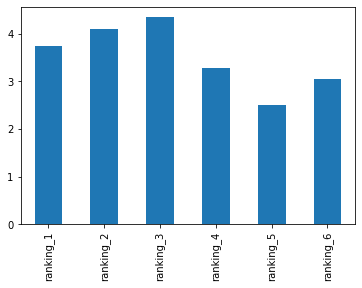

In [87]:
import matplotlib.pyplot as plt
%matplotlib inline
ranking_mean.plot.bar()

## 6. Finding the Most Viewed Movie


In [88]:
# seen columns
seen_sum = star_wars_updated[['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']].sum()
seen_sum

seen_1    673
seen_2    571
seen_3    550
seen_4    607
seen_5    758
seen_6    738
dtype: int64

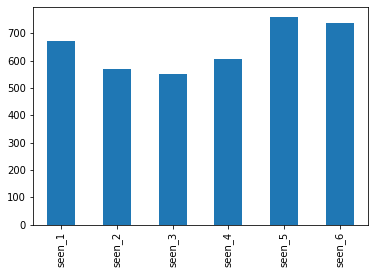

In [89]:
seen_sum.plot.bar()

## 7. Exploring the Data by Binary Segments


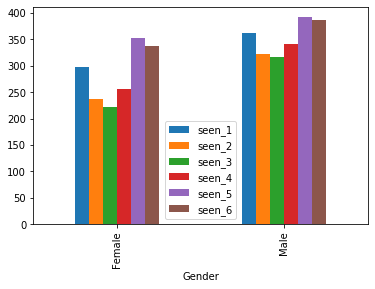

In [92]:
# split the data
cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
star_wars_updated.pivot_table(values=cols, index='Gender', aggfunc=np.sum).plot.bar()

In [91]:
cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
star_wars_updated.pivot_table(values=cols, index='Gender', aggfunc=np.sum).plot.bar()

,seen_1,seen_2,seen_3,seen_4,seen_5,seen_6
Gender,,,,,,
Female,298.0,237.0,222.0,255.0,353.0,338.0
Male,361.0,323.0,317.0,342.0,392.0,387.0


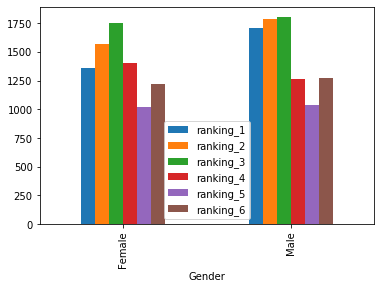

In [93]:
cols = ['ranking_1', 'ranking_2', 'ranking_3', 'ranking_4', 'ranking_5', 'ranking_6']
star_wars_updated.pivot_table(values=cols, index='Gender', aggfunc=np.sum).plot.bar()

## 8. Next Steps


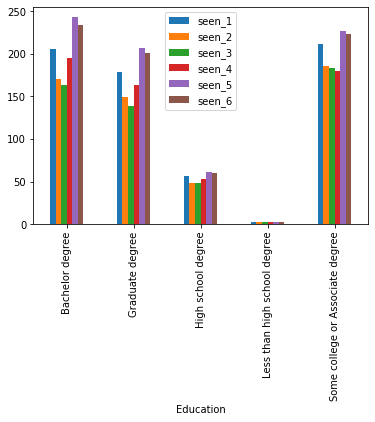

In [96]:
cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
star_wars_updated.pivot_table(values=cols, index='Education', aggfunc=np.sum).plot.bar()

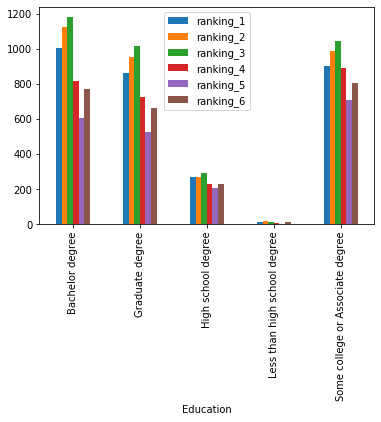

In [95]:
cols = ['ranking_1', 'ranking_2', 'ranking_3', 'ranking_4', 'ranking_5', 'ranking_6']
star_wars_updated.pivot_table(values=cols, index='Education', aggfunc=np.sum).plot.bar()

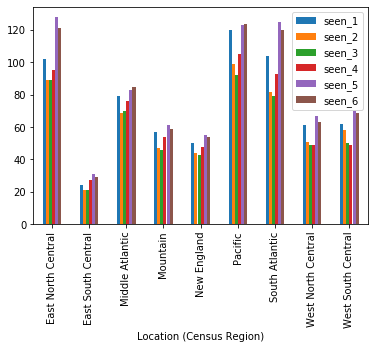

In [98]:
cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
star_wars_updated.pivot_table(values=cols, index='Location (Census Region)', aggfunc=np.sum).plot.bar()

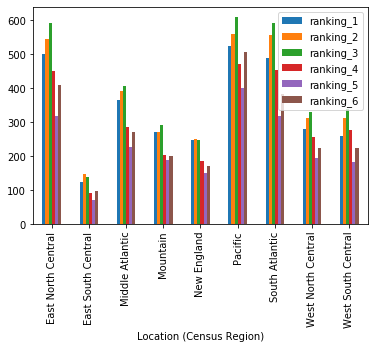

In [99]:
cols = ['ranking_1', 'ranking_2', 'ranking_3', 'ranking_4', 'ranking_5', 'ranking_6']
star_wars_updated.pivot_table(values=cols, index='Location (Census Region)', aggfunc=np.sum).plot.bar()

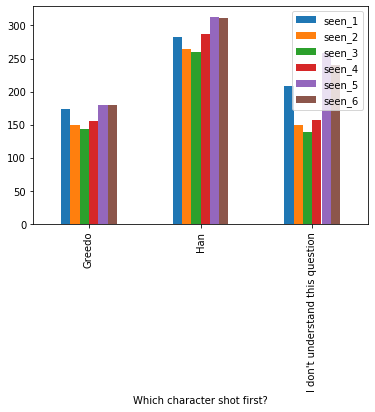

In [101]:
cols = ['seen_1', 'seen_2', 'seen_3', 'seen_4', 'seen_5', 'seen_6']
star_wars_updated.pivot_table(values=cols, index='Which character shot first?', aggfunc=np.sum).plot.bar()

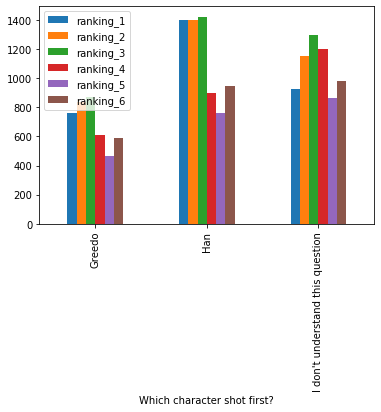

In [102]:
cols = ['ranking_1', 'ranking_2', 'ranking_3', 'ranking_4', 'ranking_5', 'ranking_6']
star_wars_updated.pivot_table(values=cols, index='Which character shot first?', aggfunc=np.sum).plot.bar()

In [104]:
columns = star_wars_updated.iloc[:, 15:29]
columns

,"Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.",Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28
1,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A)
4,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
5,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1182,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Very favorably,Very favorably,Somewhat favorably,Somewhat favorably,Very favorably
1183,Very favorably,Somewhat favorably,Very favorably,Somewhat unfavorably,Very favorably,Neither favorably nor unfavorably (neutral),Very unfavorably,Somewhat favorably,Unfamiliar (N/A),Somewhat favorably,Very favorably,Somewhat unfavorably,Somewhat unfavorably,Very favorably
1184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1185,Very favorably,Neither favorably nor unfavorably (neutral),Very favorably,Very favorably,Very favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat favorably,Very favorably,Somewhat favorably,Very favorably


In [109]:
star_wars_updated = star_wars_updated.rename(columns={'Please state whether you view the following characters favorably, unfavorably, or are unfamiliar with him/her.':'Han Solo',
                                                      'Unnamed: 16':'Luke Skywalker',
                                                      'Unnamed: 17':'Princess Leia Organa',
                                                      'Unnamed: 18':'Anakin Skywalker',
                                                      'Unnamed: 19':'Obi Wan Kenobi',
                                                      'Unnamed: 20':'Emperor Palpatine',
                                                      'Unnamed: 21':'Darth Vader',
                                                      'Unnamed: 22':'Lando Calrissian',
                                                      'Unnamed: 23':'Boba Fett',
                                                      'Unnamed: 24':'C-3P0',
                                                      'Unnamed: 25':'R2 D2',
                                                      'Unnamed: 26':'Jar Jar Binks',
                                                      'Unnamed: 27':'Padme Amidala',
                                                      'Unnamed: 28':'Yoda'}
                                            )
characters = star_wars_updated.iloc[:, 15:29]
characters.columns

Index(['Han Solo', 'Luke Skywalker', 'Princess Leia Organa',
       'Anakin Skywalker', 'Obi Wan Kenobi', 'Emperor Palpatine',
       'Darth Vader', 'Lando Calrissian', 'Boba Fett', 'C-3P0', 'R2 D2',
       'Jar Jar Binks', 'Padme Amidala', 'Yoda'],
      dtype='object')

In [127]:
characters.head()

,Han Solo,Luke Skywalker,Princess Leia Organa,Anakin Skywalker,Obi Wan Kenobi,Emperor Palpatine,Darth Vader,Lando Calrissian,Boba Fett,C-3P0,R2 D2,Jar Jar Binks,Padme Amidala,Yoda
1,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Unfamiliar (N/A),Unfamiliar (N/A),Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Somewhat favorably,Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A),Unfamiliar (N/A)
4,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably,Somewhat favorably,Very favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very favorably,Very favorably,Very favorably,Very favorably
5,Very favorably,Somewhat favorably,Somewhat favorably,Somewhat unfavorably,Very favorably,Very unfavorably,Somewhat favorably,Neither favorably nor unfavorably (neutral),Very favorably,Somewhat favorably,Somewhat favorably,Very unfavorably,Somewhat favorably,Somewhat favorably


In [136]:
characters['Han Solo'].value_counts()

Very favorably                                 610
Somewhat favorably                             151
Neither favorably nor unfavorably (neutral)     44
Unfamiliar (N/A)                                15
Somewhat unfavorably                             8
Very unfavorably                                 1
Name: Han Solo, dtype: int64

In [134]:
char_names = characters.columns
char_opinion = ['Very favorably', 
                'Somewhat favorably', 
                'Neither favorably nor unfavorably (neutral)', 
                'Unfamiliar (N/A)', 
                'Somewhat unfavorably',
                'Very unfavorably']
char_dic = {}

for each in char_names:
    char_dic[each] = characters[each].value_counts()

char_df = pd.DataFrame(data=char_dic)

In [135]:
char_df

,Han Solo,Luke Skywalker,Princess Leia Organa,Anakin Skywalker,Obi Wan Kenobi,Emperor Palpatine,Darth Vader,Lando Calrissian,Boba Fett,C-3P0,R2 D2,Jar Jar Binks,Padme Amidala,Yoda
Neither favorably nor unfavorably (neutral),44,38,48,135,43,213,84,236,248,79,57,164,207,51
Somewhat favorably,151,219,210,269,159,143,171,223,153,229,185,130,183,144
Somewhat unfavorably,8,13,12,83,8,68,102,63,96,23,10,102,58,8
Unfamiliar (N/A),15,6,8,52,17,156,10,148,132,15,10,109,164,10
Very favorably,610,552,547,245,591,110,310,142,138,474,562,112,168,605
Very unfavorably,1,3,6,39,7,124,149,8,45,7,6,204,34,8


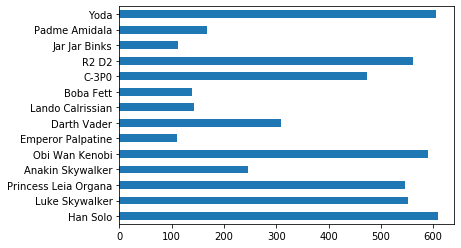

In [142]:
char_df.loc['Very favorably'].plot.barh()

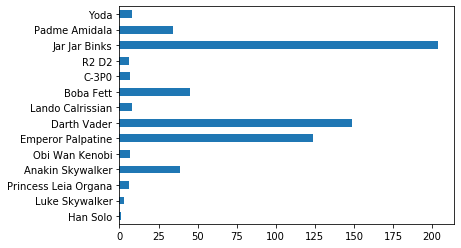

In [143]:
char_df.loc['Very unfavorably'].plot.barh()

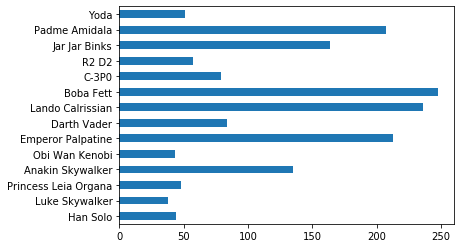

In [144]:
char_df.loc['Neither favorably nor unfavorably (neutral)'].plot.barh()